<a href="https://colab.research.google.com/github/profhannahchang/profhannahchang.github.io/blob/main/SJDM_Special_Session_Text_Analysis_Example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NLP and LLMs in JDM: A Special Session on Computational Text Analysis

By: Xinlan Emily Hu

Welcome to our SJDM Special Session! In this tutorial, we will introduce you to basic concepts in anlayzing text data and walk you through three different analyses.

✋ **NOTE** - To work through this notebook, you should create a copy of the full folder with the relevant data in your Google Drive. You can access the folder here: https://drive.google.com/drive/folders/1i91R6cB2Vms0mDV78qj-c2AScb5LadhY?usp=sharing

*With thanks to:*

Sudeep Bhatia and Mike Yeomans (co-organizers of the SJDM Special Session); I took inspiration from Sudeep's [tutorial materials](https://colab.research.google.com/drive/1oMgE0C7lqILUt_wKhiw1HxhGhNEEC96w#scrollTo=uSyrMqHeCclW), as well as [this CoLab notebook for DLATK](https://colab.research.google.com/drive/10WMCmnKzwywZR7s2et5xx9CcoWBNmhLY?usp=sharing).

# Step 0.0: Install the Team Communication Toolkit

Our demo will utilize functions featured in the [Team Communication Toolkit](https://conversational-featurizer.readthedocs.io/en/latest/index.html). This is an external package that doesn't come with Google CoLab, so we'll have to install it manually.

✋ **NOTE** - When you run the line below, it will take some time to resolve all the package dependencies. After everything resolves successfully, you'll get a warning that says something like the following:

> WARNING: The following packages were previously imported in this runtime:
  [PIL,_distutils_hack,blis,catalogue,certifi,chardet,charset_normalizer,click,confection,convokit,cycler,cymem,dateutil,dill,emoji,joblib,kiwisolver,langcodes,markupsafe,murmurhash,nltk,pkg_resources,preshed,pytz,regex,requests,setuptools,shellingham,six,smart_open,spacy,srsly,textblob,thinc,torch,torchgen,tqdm,unidecode,wasabi,wcwidth,weasel,wrapt,yaml]
You must restart the runtime in order to use newly installed versions.

> Restarting will lose all runtime state, including local variables.

At this point, follow the prompt to 'restart' your runtime and refresh your session.

**Once you are done, you can comment out this line of code and start running from the next block of code.**

In [ ]:
# comment me out once you have installed the package and restarted the runtime
!pip install --ignore-installed team_comm_tools

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.2/183.2 kB 4.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.4/175.4 kB 14.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 4.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 4.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.7/169.7 kB 13.6 MB/s eta 0:00:00
  Using cached setuptools-75.6.0-py3-none-any.whl.metadata (6.7 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.5/164.5 kB 13.1 MB/s eta 0:00:00
INFO: pip is looking at m

## Once you restart, begin running from here!

Run the following cell to confirm that you have installed the Team Communication Toolkit.

In [ ]:
!pip list | grep team_comm_tools

team_comm_tools                    0.1.4.post2


# Step 0.1: Import  Dependencies

Now, let's install the dependencies required to run our demo. When you run the following imports, it's normal to see some printouts showing that you've install additional dependencies. That might include something like this:

> [nltk_data] Downloading package stopwords to /root/nltk_data...

> [nltk_data]   Package stopwords is already up-to-date!

> [nltk_data] Downloading package nps_chat to /root/nltk_data...

> [nltk_data]   Unzipping corpora/nps_chat.zip.

> [nltk_data] Downloading package punkt_tab to /root/nltk_data...

> [nltk_data]   Unzipping tokenizers/punkt_tab.zip.

> [nltk_data] Downloading package wordnet to /root/nltk_data...



In [ ]:
import pandas as pd
import numpy as np
import re
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt
from team_comm_tools import FeatureBuilder
from google.colab import drive
import os

[nltk_data] Downloading package nps_chat to /root/nltk_data...
[nltk_data]   Unzipping corpora/nps_chat.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.7k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/501M [00:00<?, ?B/s]

Next, we'll need to "mount" the CoLab notebook onto Google Drive so that we can access the dataset.

✋ At this stage, you should see a pop-up asking for your permission to access your Google Drive. This is what allows us to read in data!

In [ ]:
drive.mount('/content/drive/')
os.chdir('/content')

Mounted at /content/drive/


Because we'll be reading from the data files, it's faster if we upload the data files to CoLab's 'local' storage, rather than having to read them from Google Drive. The following three lines of code creates a new folder called `gap_analysis` under "Files."

✋**Note** - remember, you should point to a local copy of the materials, which you can find at [this Google Folder link](https://drive.google.com/drive/folders/1i91R6cB2Vms0mDV78qj-c2AScb5LadhY?usp=drive_link)!

In [ ]:
!mkdir -p /content/gap_analysis
# TODO -- change this to the location where the folder lives in **YOUR** drive!
!cp -r "/content/drive/MyDrive/Academic Work/Text Analysis Workshop/Text Analysis Demo/"* /content/gap_analysis/
%cd /content/gap_analysis

/content/gap_analysis


# Step 1: Load the Data

The data we'll be using for this tutorial is called the [Group Affect and Performance (GAP) Corpus](https://sites.google.com/view/gap-corpus/home), a collection of 28 team conversations in which teams work to solve a "winter survival" task (ranking a series of items in terms of how critical they are for a survival situation). Here is a brief description of the corpus from the website:

> The Group Affect and Performance (GAP) Corpus has been collected at University of the Fraser Valley (UFV, Canada). It is being made available to researchers to help facilitate research on computational approaches to small group interaction.

> The GAP Corpus uses a winter survival task scenario, with participants first completing a ranking task individually and then performing the same ranking task jointly as a group.  All of the group conversations are in English.

The version of the data that we'll be using in this tutorial is a slightly cleaned up version (merging some of the dataframes in the original data file for convenient analysis).

In [ ]:
df_gap_corpus = pd.read_csv('gap_corpus_demo.csv')

First, let's familiarize ourselves with what the dataset contains. We'll use the `.head()` function to take a peek at the initial five rows of the data.

The first few columns of the dataset pertain to the conversation and its metadata:
- `speaker_id`: identifier of the person speaking
- `message`: content of what is being said in a given utterance
- `conversation_id`: identifier of the group (each group is one unique conversation)
- `timestamp_start`: the starting point of the utterance
- `timestamp_end`: the ending point of the utterance

Additionally, the last few rows of the dataset represent potential dependent variables or moderators:

- Absolute Group Score on the winter survival task (**AGS**; this was the primary dependent variable in the original study, and the remaining variables are additional post-activity survey measures.)
- Group Time Expectation (**Group_TE**)
- Group Worked Well Together (**Group_WW**)
- Group Time Management (**Group_TM)**
- Group Efficiency (**Group_Eff**)
- Group Quality of Work (**Group_QW**)
- Group Overall Satisfaction with Meeting (**Group_Sat**)

## Basic Data Description

On average, there are 3 individuals per conversation. The distribution of speakers in the conversations looks something like this:



Mean number of participants per group:
3.0


<Axes: >

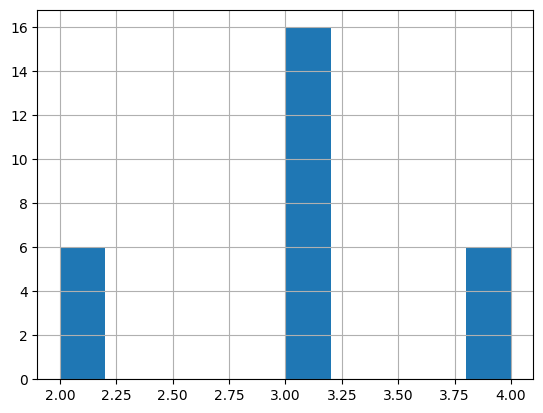

In [ ]:
print("Mean number of participants per group:")
print(np.mean(df_gap_corpus.groupby("conversation_id")["speaker_id"].nunique().mean()))
df_gap_corpus.groupby("conversation_id")["speaker_id"].nunique().hist()

# Step 2: Run Exploratory Analysis

The next step is to run some exploratory analyses. In this demo, we'll be highlighting three different types of analyses:

- a lexical measure of certainty (from Rocklage et al., 2023);
- a measure of positive sentiment (using a pretrained RoBERTa model);
- a measure of how much, on average, the messages in a conversation thus far 'mimic' the preceding messages (as measured by SBERT vectors).

Fortunately for us, all of these measures are already available in the Team Communication Toolkit, which is a package wrapper that implements these and many other features into a single function call.

We'll simply declare a `FeatureBuilder` object and run it on our data --- once it completes, we can explore each of these three measures in more detail.

In [ ]:
feature_builder = FeatureBuilder(
        input_df = df_gap_corpus,
        conversation_id_col = "conversation_id",
        speaker_id_col = "speaker_id",
        message_col = "message",
        timestamp_col = ["timestamp_start", "timestamp_end"],
        vector_directory = "vector_data/",
        output_file_base = "gap_corpus_demo",
        custom_features = ["Moving Mimicry"]
)
feature_builder.featurize()

Initializing Featurization...
Confirmed that data has conversation_id: conversation_id, speaker_id: speaker_id and message: message columns!
Chat Level Features ...


100%|██████████| 16/16 [06:37<00:00, 24.84s/it]


Generating features for the first 100.0% of messages...
Generating User Level Features ...
Generating Conversation Level Features ...


All Done!


# Step 3: Exploring how measures of conversation relat to group outcomes

In this final step, we demo ways in which the structued extraction of conversational features can help us explore a research question of interest --- in this case, whether different conversational attributes correlate with the group's performance (Absolute Group Score, or AGS), or its self-reported measures of efficacy and satisfaction.

In [ ]:
# read in the chat output
df_chat_output = pd.read_csv('output/chat/gap_corpus_demo_chat_level.csv')

Recall that we have the following dependent variables available:

In [ ]:
dvs = ['AGS', 'Group_TE', 'Group_WW', 'Group_TM', 'Group_Eff', 'Group_QW', 'Group_Sat']

Although the toolkit generates a number of conversational features, for the purposes of this demo, we'll focus on a small selection of three of them: (1) Certainty; (2) Positive Sentiment; and (3) Mimicry.

In [ ]:
iv_of_interest = ["certainty_rocklage", "positivity_zscore_chats", "moving_mimicry"]

## Correlate Conversation Measures with DV's

First, let's take a quick glance: which dependent measures correlate with our three focal conversation features?

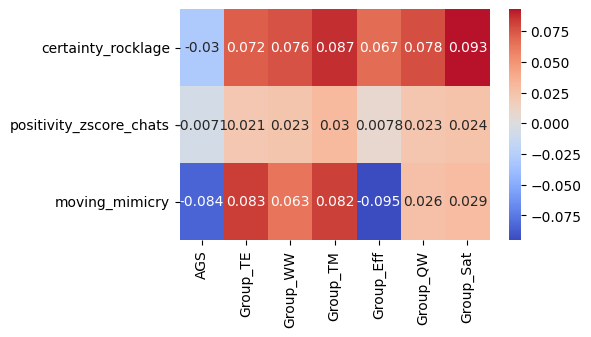

In [ ]:
corrs_with_dvs = df_chat_output[iv_of_interest+list(dvs)].corr()[list(dvs)].dropna()
# remove the rows representing dv's from the correlation
corrs_with_dvs = corrs_with_dvs.drop(index=dvs)
corrs_with_dvs.sort_values(by="AGS", ascending=False)

plt.figure(figsize=(5, 3))
sns.heatmap(corrs_with_dvs, annot=True, cmap="coolwarm", center=0)
plt.show()

## Some Regression Analyses

Here, we see some basic correlations; while most of these correlations are quite weak, we notice that, relatively speaking, mimicry is negatively correlated with performance (AGS), and that certainty seems positively correlated with group satisfaction.

Can we dig into these findings a bit more? For example, what if we fit a linear model using the conversations features as the independent variables?

In [ ]:
# create a variable that combines speaker ID + conversation ID, as we want to cluster
# both by the individual, and by the group they were in
df_chat_output['group_speaker_id'] = df_chat_output['conversation_id'].astype(str) + '_' + df_chat_output['speaker_id'].astype(str)

In [ ]:
y = df_chat_output["AGS"].astype(float)
X = df_chat_output[["moving_mimicry"]]
X = sm.add_constant(X)
model = sm.OLS(y, X)
results_cons22 = model.fit(cov_type='cluster', cov_kwds={'groups': df_chat_output['group_speaker_id']})
print(results_cons22.summary())

                            OLS Regression Results                            
Dep. Variable:                    AGS   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     1.127
Date:                Mon, 25 Nov 2024   Prob (F-statistic):              0.292
Time:                        06:38:25   Log-Likelihood:                -32126.
No. Observations:                8009   AIC:                         6.426e+04
Df Residuals:                    8007   BIC:                         6.427e+04
Df Model:                           1                                         
Covariance Type:              cluster                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             85.2869     11.192      7.

In [ ]:
y = df_chat_output["Group_Sat"].astype(float)
X = df_chat_output[["certainty_rocklage"]]
X = sm.add_constant(X)
model = sm.OLS(y, X)
results_cons22 = model.fit(cov_type='cluster', cov_kwds={'groups': df_chat_output['group_speaker_id']})
print(results_cons22.summary())

                            OLS Regression Results                            
Dep. Variable:              Group_Sat   R-squared:                       0.009
Model:                            OLS   Adj. R-squared:                  0.008
Method:                 Least Squares   F-statistic:                     14.19
Date:                Mon, 25 Nov 2024   Prob (F-statistic):           0.000308
Time:                        06:38:28   Log-Likelihood:                -5787.1
No. Observations:                8009   AIC:                         1.158e+04
Df Residuals:                    8007   BIC:                         1.159e+04
Df Model:                           1                                         
Covariance Type:              cluster                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  3.9679      0

## Inspect the features a bit more

But what are our measures really measuring?

### Certainty
It seems like the messages that display the most certainty are those that are advocating for the importance of specific objects (e.g., "it is definitely important," "Rope is definitely more important than a chocolate bar").

In [ ]:
df_chat_output[["certainty_rocklage", "message_original"]].sort_values(by="certainty_rocklage", ascending=False).head(5)

,certainty_rocklage,message_original
1681,8.59,"""But it is definitely important."""
7573,8.59,"""Rope is definitely more important than a choc..."
4667,8.48,"""I wasnt precise like the exact order obviously."""
7167,8.48,"""But at this exact moment in time, I do not fe..."
7434,8.30,"""Im sure theres some use for it, um."""


But what's also interesting is that the *least* certain messages might actually be reflecting an artifact of annotation --- in which muffled or mumbling speech is marked as `[unclear]`. Could it be that, in this case, the feature is really just measuring instances of mumbled or quiet talking?

Here, we've discovered something in the data, and in the next round of analyses, we should be careful to handle this particular marker.

In [ ]:
df_chat_output[["certainty_rocklage", "message_original"]].sort_values(by="certainty_rocklage", ascending=False).tail(10)

,certainty_rocklage,message_original
3219,1.1,"""You could use one of the extra shirts to put ..."
3215,1.1,"""Thats what mine was [unclear]."""
3213,1.1,"""Okay yeah yeah thats stupid [unclear]."""
2177,1.1,"""[Unclear]."""
5769,1.1,"""Manitoba [unclear]."""
3188,1.1,"""[unclear]"""
225,1.1,"""[unclear]"""
5771,1.1,"""I mean [unclear]."""
5773,1.1,"""[unclear]"""
5858,1.1,"""Useful [unclear]."""


### Positivity

Positivity works as we expect. However, as we saw earlier in the workshop, we should be careful to note whether the causal arrow is going in one direction (i.e., "That's great" and other positive language leads to team success) or the other way around (i.e., teams only say "that's great" when they're already doing well).

In [ ]:
df_chat_output[["positivity_zscore_chats", "message_original"]].sort_values(by="positivity_zscore_chats", ascending=False)

,positivity_zscore_chats,message_original
6705,4.218510,"""This is so fun actually I love this idea $."""
1160,4.182681,"""That sounds terrific."""
4172,4.167321,"""Yeah thats perfect."""
172,4.166389,"""Thats great."""
7812,4.160828,"""Awesome."""
...,...,...
3416,-1.026057,"""Cause of it will not lighten up."""
6607,-1.028479,"""I mean it sucks theres no fluid but."""
3213,-1.029920,"""Okay yeah yeah thats stupid [unclear]."""
7758,-1.030098,"""Cause the pilot and co-pilot have been killed."""


### Mimicry

Lastly, we look at the features that have the highest and lowest mimicry scores.

For high-mimicry scores, it seems like the vast majority of the utterances are super short (e.g., "Three") --- parts of the conversation where people seem to be coordinating the numbered items.

In [ ]:
# create a variable for each conversation ID that measures the index of the message
df_chat_output['message_index'] = df_chat_output.groupby('conversation_id').cumcount()

In [ ]:
df_chat_output[["moving_mimicry", "message_index", "message_original"]].sort_values(by="moving_mimicry", ascending=False).head(10)

,moving_mimicry,message_index,message_original
2788,0.790470,3,"""Yeah."""
5273,0.763647,37,"""Three."""
5274,0.758441,38,"""Okay, so, I did eight."""
5272,0.757081,36,"""Three."""
5276,0.755829,40,"""Four."""
5278,0.754814,42,"""Ten."""
5279,0.754782,43,"""Twelve."""
5271,0.754396,35,"""Two."""
5275,0.753503,39,"""Three."""
5277,0.752784,41,"""Eleven."""


For low-mimicry utterances, we notice that, because it is the first message in a conversation, the mimicry score of the first message is always zero.

In [ ]:
df_chat_output[["moving_mimicry", "message_index", "message_original"]].sort_values(by="moving_mimicry", ascending=False).tail(10)

,moving_mimicry,message_index,message_original
7495,0.0,0,"""Okay."""
1841,0.0,0,"""Okay, um, so what I wrote my first priority w..."
3661,0.0,0,"""Okay, so the first thing we would have to dec..."
2036,0.0,0,"""Alright."""
2382,0.0,0,"""Alright."""
2785,0.0,0,"""Were we supposed to write them as a group?"""
2956,0.0,0,"""What did you guys put for number one?"""
6578,0.0,0,"""Sweet."""
3353,0.0,0,"""Okay, so what do you think we should rank fir..."
0,0.0,0,"""Okay, so what did everyone put for their most..."


Thus, when there's a negative correlation, could it be that the feature is really picking up the notion of **temporality** (there's something about the first messages in a conversation we should pay attention to), rather than mimicry per se?

Is there a way to design a better version of this measure (or a better use of this measure) to account for this phenomenon? (This is the open-ended part of research using text data!)

In each of these cases, we see that, while it's easy to examine the correlation or fit a regression, truly understanding what's "going on" requires examining the underlying text --- and combining computational measures with a deeper understanding of context.